In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries loaded")

Libraries loaded


In [2]:
import pandas as pd

offsides_path = "../data/raw/OFFSIDES.csv"

offsides = pd.read_csv(offsides_path)

print("OFFSIDES shape:", offsides.shape)
offsides.head()

C:\Users\Kritika Taank\AppData\Local\Temp\ipykernel_27572\1827996419.py:5: DtypeWarning: Columns (0,2,4,5,6,7,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  offsides = pd.read_csv(offsides_path)


OFFSIDES shape: (3206558, 11)


,drug_rxnorn_id,drug_concept_name,condition_meddra_id,condition_concept_name,A,B,C,D,PRR,PRR_error,mean_reporting_frequency
0,4024,"ergoloid mesylates, USP",10002034,Anaemia,6,126,21,1299,2.85714,0.45382,0.045455
1,4024,"ergoloid mesylates, USP",10002965,Aplasia pure red cell,1,131,1,1319,10.0,1.41126,0.007576
2,4024,"ergoloid mesylates, USP",10013442,Disseminated intravascular coagulation,1,131,6,1314,1.66667,1.07626,0.007576
3,4024,"ergoloid mesylates, USP",10023126,Jaundice,2,130,7,1313,2.85714,0.79657,0.015152
4,4024,"ergoloid mesylates, USP",10016288,Febrile neutropenia,1,131,5,1315,2.0,1.09163,0.007576


In [3]:
offsides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3206558 entries, 0 to 3206557
Data columns (total 11 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   drug_rxnorn_id            object
 1   drug_concept_name         object
 2   condition_meddra_id       object
 3   condition_concept_name    object
 4   A                         object
 5   B                         object
 6   C                         object
 7   D                         object
 8   PRR                       object
 9   PRR_error                 object
 10  mean_reporting_frequency  object
dtypes: object(11)
memory usage: 269.1+ MB


In [4]:
offsides.isnull().sum()

drug_rxnorn_id              0
drug_concept_name           0
condition_meddra_id         0
condition_concept_name      0
A                           0
B                           0
C                           0
D                           0
PRR                         0
PRR_error                   3
mean_reporting_frequency    0
dtype: int64

In [5]:
offsides.describe()

,drug_rxnorn_id,drug_concept_name,condition_meddra_id,condition_concept_name,A,B,C,D,PRR,PRR_error,mean_reporting_frequency
count,3206558,3206558,3206558,3206558,3206558,3206558,3206558,3206558,3206558.0,3.206555e+06,3.206558e+06
unique,2787,2730,24706,14544,3986,61758,14688,281309,108652.0,5.312740e+05,1.223390e+05
top,36567,Hydrochlorothiazide,10028813,Nausea,1,49652,1,576349,10.0,1.414200e+00,2.013980e-05
freq,16266,22446,2299,2347,1159237,3690,210136,574,209153.0,1.552300e+04,3.690000e+03


<Axes: title={'center': 'Top Drugs in OFFSIDES'}, xlabel='drug_concept_name'>

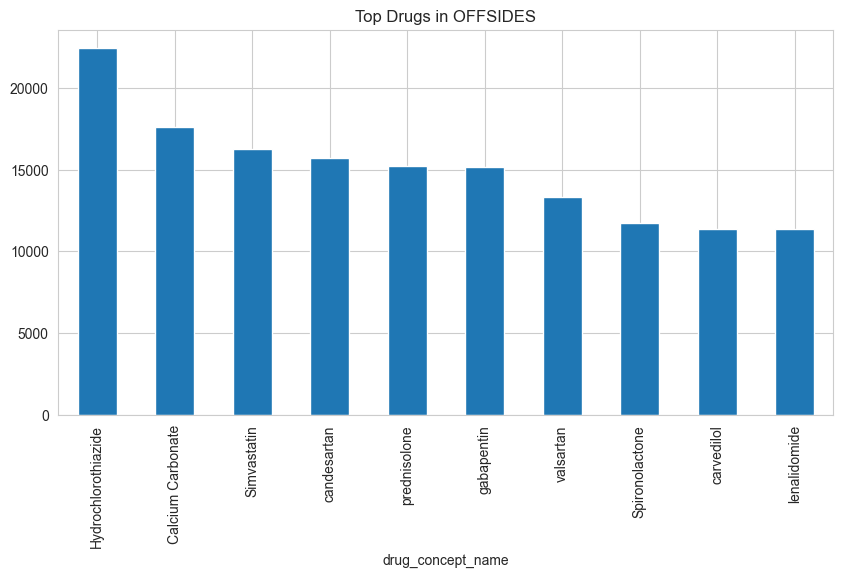

In [6]:
top_drugs = offsides["drug_concept_name"].value_counts().head(10)

top_drugs.plot(kind="bar", figsize=(10,5), title="Top Drugs in OFFSIDES")

In [9]:
numeric_cols = ["A", "B", "C", "D", "PRR", "PRR_error", "mean_reporting_frequency"]

for col in numeric_cols:
    offsides[col] = pd.to_numeric(offsides[col], errors="coerce")

In [10]:
offsides[numeric_cols].dtypes

A                           float64
B                           float64
C                           float64
D                           float64
PRR                         float64
PRR_error                   float64
mean_reporting_frequency    float64
dtype: object

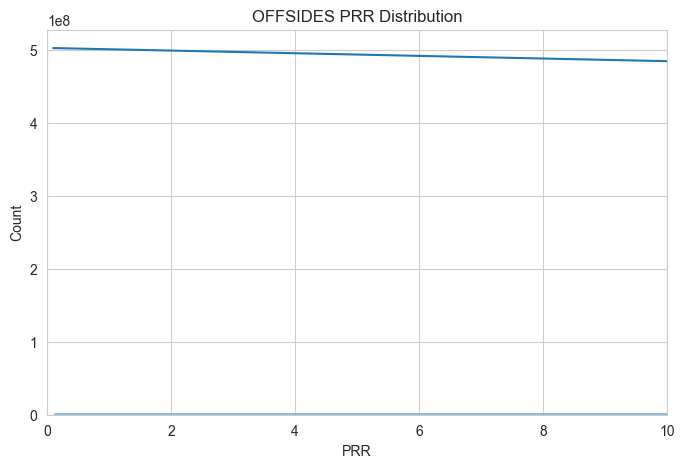

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(offsides["PRR"], bins=50, kde=True)
plt.title("OFFSIDES PRR Distribution")
plt.xlim(0, 10)
plt.show()

<Axes: title={'center': 'Top Side Effects'}, xlabel='condition_concept_name'>

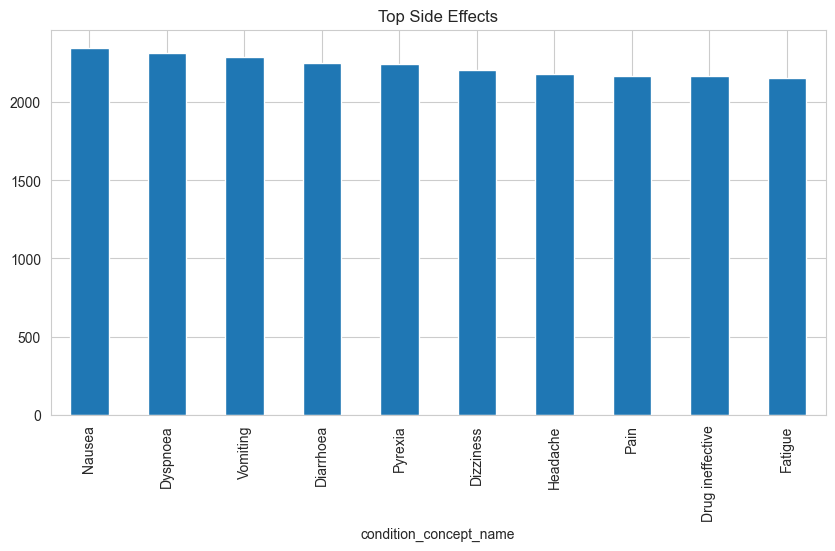

In [8]:
top_effects = offsides["condition_concept_name"].value_counts().head(10)

top_effects.plot(kind="bar", figsize=(10,5), title="Top Side Effects")

In [2]:
import pandas as pd

twosides_path = "../data/raw/TWOSIDES.csv"

twosides = pd.read_csv(twosides_path)

print("TWOSIDES shape:", twosides.shape)
twosides.head()

C:\Users\Kritika Taank\AppData\Local\Temp\ipykernel_17576\540721279.py:5: DtypeWarning: Columns (0,2,4,6,7,8,9,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  twosides = pd.read_csv(twosides_path)


TWOSIDES shape: (42920391, 13)


,drug_1_rxnorn_id,drug_1_concept_name,drug_2_rxnorm_id,drug_2_concept_name,condition_meddra_id,condition_concept_name,A,B,C,D,PRR,PRR_error,mean_reporting_frequency
0,10355,Temazepam,136411,sildenafil,10003239,Arthralgia,7,149,24,1536,2.91667,0.421275,0.0448718
1,1808,Bumetanide,7824,Oxytocin,10003239,Arthralgia,1,13,2,138,5.0,1.19224,0.0714286
2,221147,POLYETHYLENE GLYCOL 3350,5521,Hydroxychloroquine,10003239,Arthralgia,6,103,20,1070,3.0,0.454505,0.0550459
3,10324,Tamoxifen,8640,Prednisone,10012735,Diarrhoea,18,123,35,1375,5.14286,0.276271,0.12766
4,10355,Temazepam,136411,sildenafil,10012735,Diarrhoea,2,154,37,1523,0.540541,0.721093,0.0128205


In [3]:
twosides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42920391 entries, 0 to 42920390
Data columns (total 13 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   drug_1_rxnorn_id          object
 1   drug_1_concept_name       object
 2   drug_2_rxnorm_id          object
 3   drug_2_concept_name       object
 4   condition_meddra_id       object
 5   condition_concept_name    object
 6   A                         object
 7   B                         object
 8   C                         object
 9   D                         object
 10  PRR                       object
 11  PRR_error                 object
 12  mean_reporting_frequency  object
dtypes: object(13)
memory usage: 4.2+ GB
